In [15]:
import torch
torch.__version__

'2.6.0+cpu'

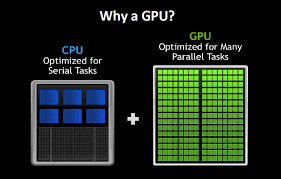

In [16]:
!nvidia-smi

Tue Jul 22 23:13:23 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.07                 Driver Version: 566.07         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   49C    P5              3W /   80W |     299MiB /   4096MiB |     10%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

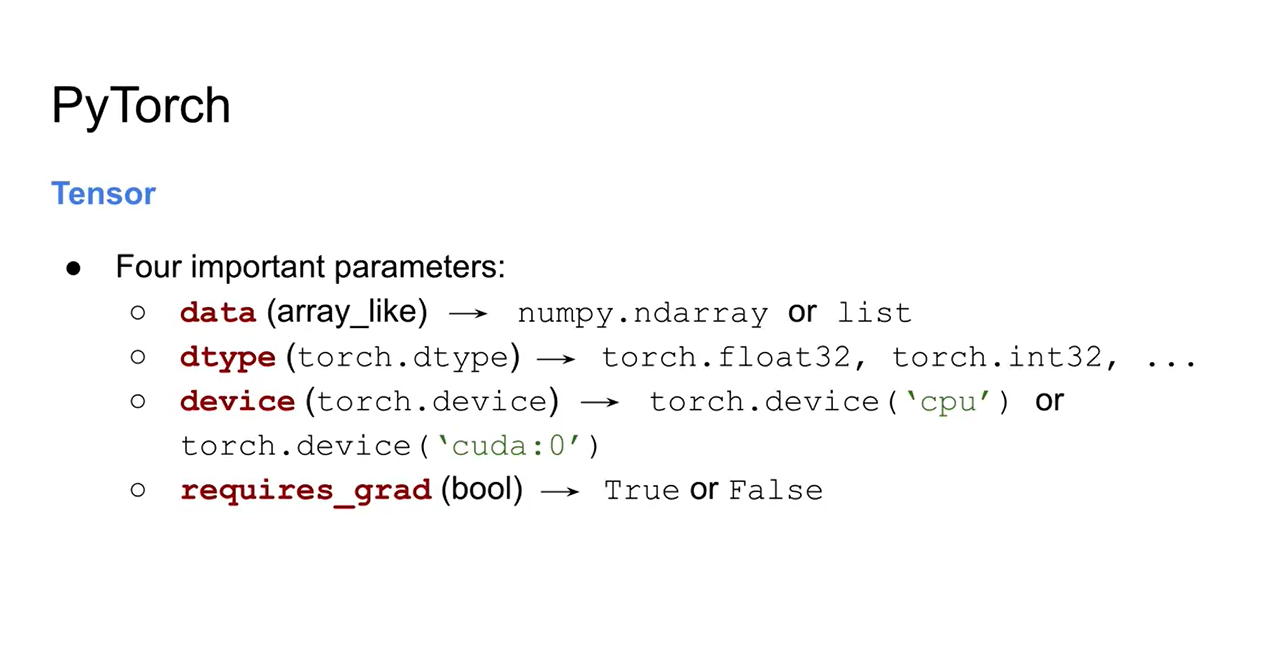

In [17]:
torch.cuda.is_available()

False

## nn package

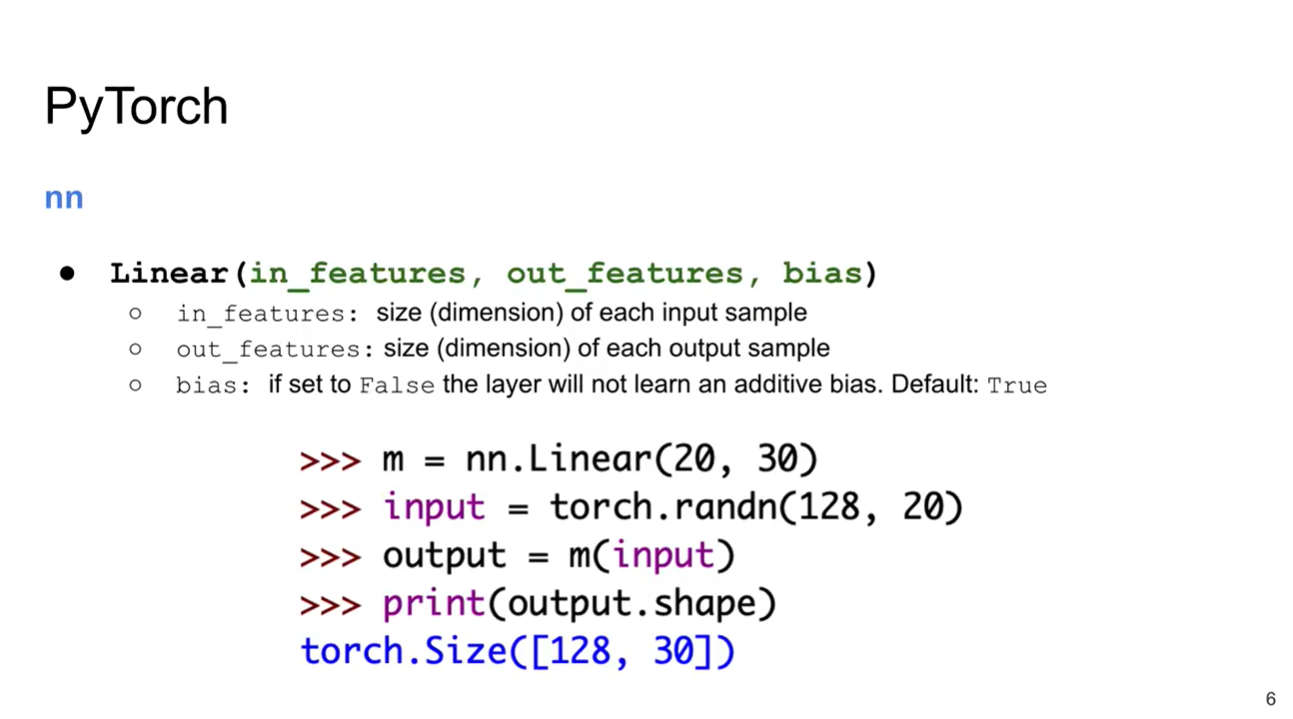

In [18]:
from torch import nn

layer = nn.Linear(5, 6)
input = torch.randn(100, 5)
output = layer(input)
print(output.shape)

print(layer.weight)
print(layer.bias)


torch.Size([100, 6])
Parameter containing:
tensor([[ 0.3384,  0.2925, -0.1255, -0.2019,  0.2063],
        [-0.3459,  0.0584, -0.0114, -0.0328,  0.2883],
        [ 0.4444, -0.2142, -0.4132, -0.0307,  0.3233],
        [ 0.0295, -0.0634, -0.0897,  0.1176,  0.1383],
        [ 0.3453,  0.2158, -0.0265, -0.2316, -0.3479],
        [-0.2921, -0.2890,  0.2615, -0.3720, -0.3384]], requires_grad=True)
Parameter containing:
tensor([ 0.3231,  0.4330, -0.2336,  0.0651,  0.0101,  0.1327],
       requires_grad=True)


In [19]:
print(type(layer.weight))

<class 'torch.nn.parameter.Parameter'>


In [20]:
x = torch.ones([1,2], device='cuda:0')
y = torch.ones([1,2], device='cpu')

print(x+y)

AssertionError: Torch not compiled with CUDA enabled

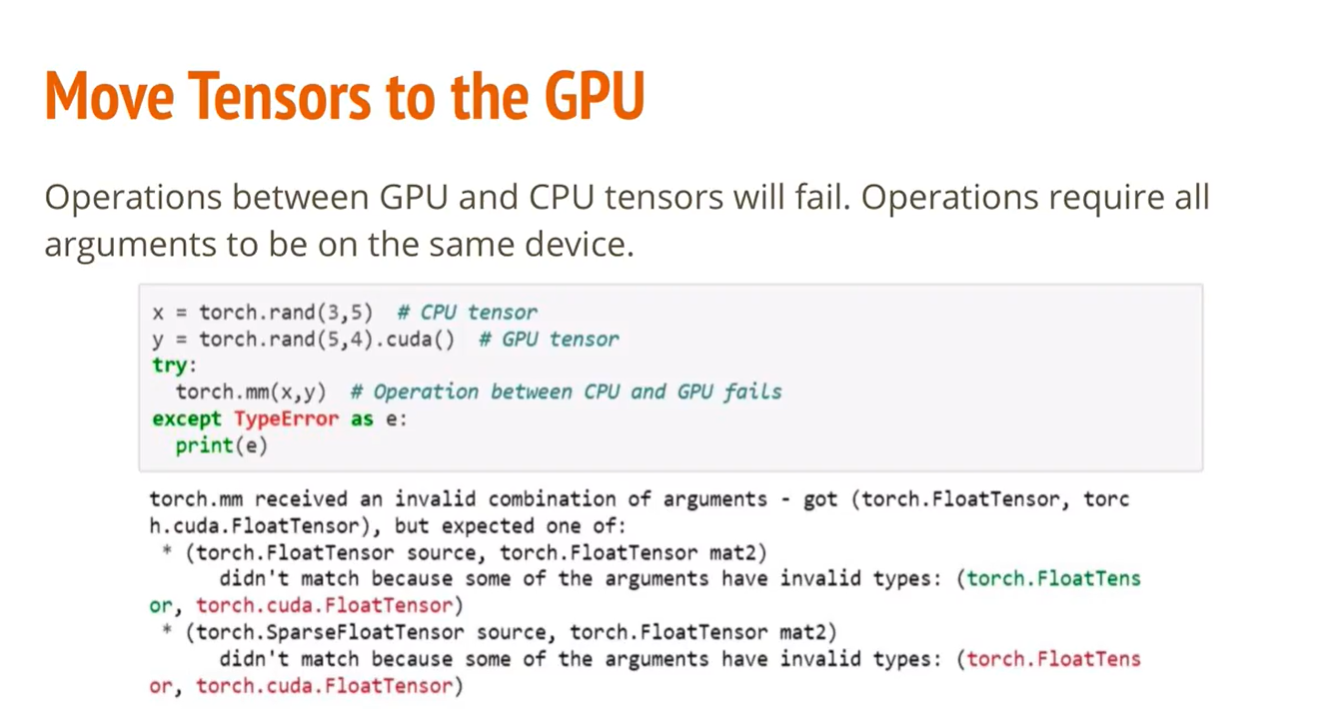

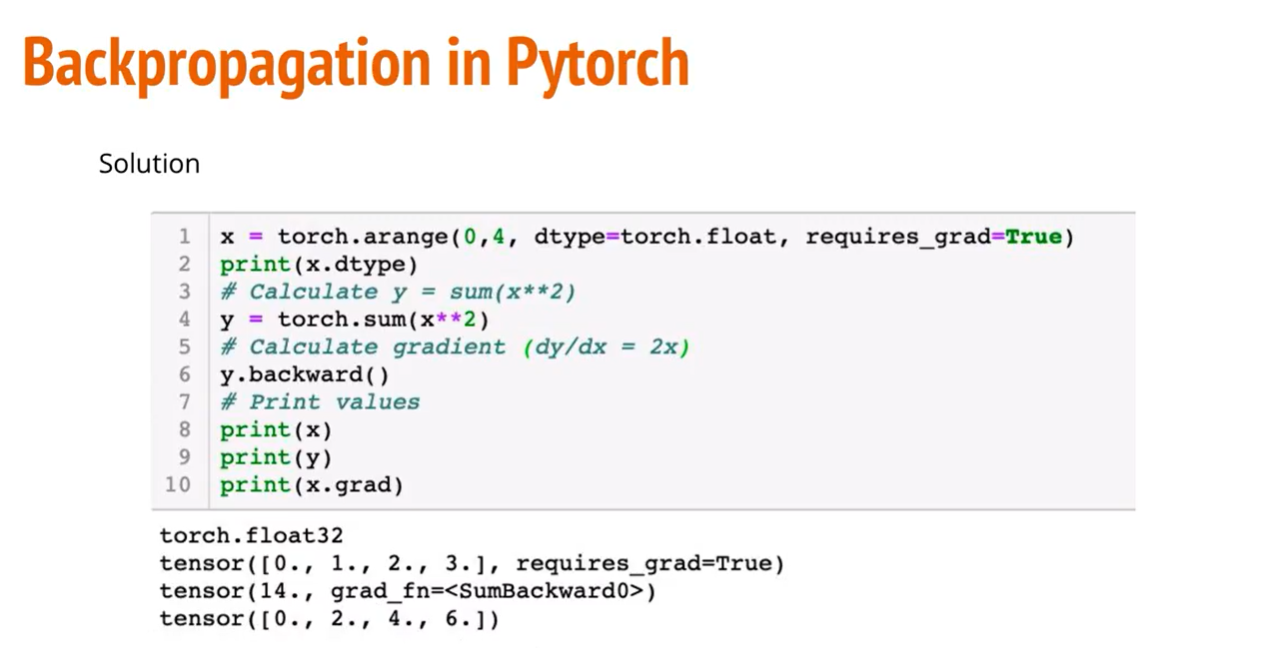

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

x = torch.randn(1, 3, requires_grad=False)  # Leaf tensor
print("x.requires_grad:", x.requires_grad)
print("x.is_leaf:", x.is_leaf)

layer1 = nn.Linear(3, 5)  # input to hidden1
for param in layer1.parameters():
    param.requires_grad = True  # freeze parameters
layer2 = nn.Linear(5, 4)  # hidden1 to hidden2
# for param in layer2.parameters():
#     param.requires_grad = False  # freeze parameters
print("layer1.weight.requires_grad:", layer2.weight.requires_grad)
print("layer1.bias.requires_grad:", layer2.bias.requires_grad)
layer3 = nn.Linear(4, 1)  # hidden2 to output

# Forward pass
h1 = F.relu(layer1(x))
# h1.retain_grad()  # Retain gradients for backward pass
h2 = F.relu(layer2(h1))
h2.retain_grad()
output = layer3(h2)  # Final prediction (scalar)

print("\nLayer outputs:")
print("h1.requires_grad:", h1.requires_grad)
print("h1.is_leaf:", h1.is_leaf)
print("output.requires_grad:", output.requires_grad)
print("h2.requires_grad:", h2.requires_grad)
print("h2.is_leaf:", h2.is_leaf)


# Define dummy target and loss
target = torch.tensor([[1.0]])
loss = F.mse_loss(output, target)  # scalar loss

# Backward pass
loss.backward()

# Inspect gradients
print("\n--- Gradients after backward() ---")
print("x.grad:", x.grad)                        #  dy/dx
print("h1.grad:", h1.grad)                      #  dy/dh1 (retained)
print("h2.grad:", h2.grad)                      #  dy/dh2 (retained)
print("output.grad:", output.grad)              #  dy/doutput (retained)

print("\nLayer weight gradients:")
print("layer1.weight.grad:", layer1.weight.grad)
print("layer2.weight.grad:", layer2.weight.grad)
print("layer3.weight.grad:", layer3.weight.grad)

#  Update input x manually using gradient (e.g., adversarial attack step)
# learning_rate = 0.01
# with torch.no_grad():  # disable gradient tracking for update
#     x -= learning_rate * x.grad
#     print("\nUpdated input x:\n", x)

x.requires_grad: False
x.is_leaf: True
layer1.weight.requires_grad: True
layer1.bias.requires_grad: True

Layer outputs:
h1.requires_grad: True
h1.is_leaf: False
output.requires_grad: True
h2.requires_grad: True
h2.is_leaf: False

--- Gradients after backward() ---
x.grad: None
h1.grad: None
h2.grad: tensor([[-0.6497, -0.8060,  0.1730, -0.1223]])
output.grad: None

Layer weight gradients:
layer1.weight.grad: tensor([[ 0.2234, -0.0192, -0.2488],
        [-0.0250,  0.0021,  0.0278],
        [ 0.1361, -0.0117, -0.1516],
        [-0.0000,  0.0000,  0.0000],
        [ 0.1071, -0.0092, -0.1193]])
layer2.weight.grad: tensor([[-0.5699, -0.1671, -0.0552, -0.0000, -0.1320],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [-0.1073, -0.0315, -0.0104, -0.0000, -0.0249]])
layer3.weight.grad: tensor([[-2.0461,  0.0000,  0.0000, -0.1224]])


C:\Users\Radin\AppData\Local\Temp\ipykernel_14328\4062376712.py:44: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\build\aten\src\ATen/core/TensorBody.h:494.)
  print("h1.grad:", h1.grad)                      #  dy/dh1 (retained)
C:\Users\Radin\AppData\Local\Temp\ipykernel_14328\4062376712.py:46: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_gr

In [22]:
print(layer1.weight.grad)

tensor([[ 0.2234, -0.0192, -0.2488],
        [-0.0250,  0.0021,  0.0278],
        [ 0.1361, -0.0117, -0.1516],
        [-0.0000,  0.0000,  0.0000],
        [ 0.1071, -0.0092, -0.1193]])


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

In [24]:
# Config
num_workers = 1
batch_size = 128
val_size = 0.1
n_epochs = 20
print_every = 500
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [25]:
# Data transforms
transform = transforms.ToTensor()
x=transform(np.array(np.ones([4,3,2])))
print(x.size())

torch.Size([2, 4, 3])


In [26]:
# prompt: show me a good transform for mnist, with random crop and rotate

transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomCrop(28, padding=4),
    transforms.ToTensor(),
])

In [27]:
train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

In [28]:
train_data[100][1]

5

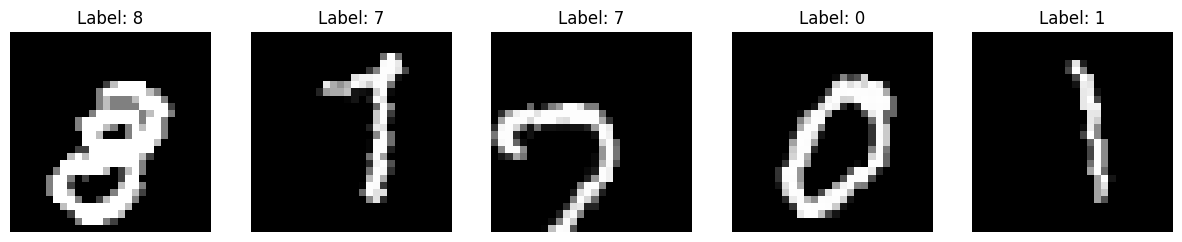

In [29]:
num_images = 5

# get random indices
indices = np.random.choice(len(train_data), size=num_images, replace=False)

# plot the images
fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
for i, idx in enumerate(indices):
  image, label = train_data[idx]
  axes[i].imshow(image.squeeze(), cmap='gray')
  axes[i].set_title(f"Label: {label}")
  axes[i].axis('off')
plt.show()

In [30]:
num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int((val_size * num_train))
train_indices, val_indices = indices[split:], indices[:split]

In [ ]:
# Create train and val subsets
train_subset = Subset(train_data, train_indices)
val_subset = Subset(train_data, val_indices)

# DataLoaders without samplers
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [ ]:
(next(iter(test_loader)))[0].shape

torch.Size([128, 1, 28, 28])

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
# Config
num_workers = 4
batch_size = 128
val_size = 0.1
n_epochs = 20
print_every = 500
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Data transforms
transform = transforms.ToTensor()

# Load datasets
train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

# Create validation split
num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(val_size * num_train))
train_indices, val_indices = indices[split:], indices[:split]

train_subset = Subset(train_data, train_indices)
val_subset = Subset(train_data, val_indices)

# DataLoaders without samplers
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# Define network
class Net(nn.Module):
    def __init__(self, input_size=28*28, hidden_1=512, hidden_2=512 , num_classes=10):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.fc3 = nn.Linear(hidden_2, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten dynamically
        # print(x.size())
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize model
model = Net(input_size=28*28, hidden_1=512, hidden_2=512 , num_classes=10)
model.to(device)

# for param in model.fc1.parameters():
#     param.requires_grad = False  # freeze parameters


# Optimizer and loss
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()


# Training loop
val_loss_min = np.inf    # float('inf')

for epoch in range(n_epochs):
    train_loss = 0
    model.train()

    for iteration, (data, label) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data.to(device))
        loss = criterion(output, label.to(device))
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * data.size(0)

        if iteration % print_every == 0:
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for data, label in val_loader:
                    output = model(data.to(device))
                    loss = criterion(output, label.to(device))
                    val_loss += loss.item() * data.size(0)

            train_loss_avg = train_loss / len(train_loader.dataset)
            val_loss_avg = val_loss / len(val_loader.dataset)
            print(f'Epoch {epoch+1}/{n_epochs}, Iteration {iteration}, Train Loss: {train_loss_avg:.4f}, Val Loss: {val_loss_avg:.4f}')

            if val_loss_avg < val_loss_min:
                print('Validation loss decreased. Saving model...')
                torch.save(model.state_dict(), 'mnist_model.pt')
                val_loss_min = val_loss_avg
            model.train()

Epoch 1/20, Iteration 0, Train Loss: 0.0055, Val Loss: 2.3014
Validation loss decreased. Saving model...
Epoch 2/20, Iteration 0, Train Loss: 0.0043, Val Loss: 1.7762
Validation loss decreased. Saving model...
Epoch 3/20, Iteration 0, Train Loss: 0.0019, Val Loss: 0.7423
Validation loss decreased. Saving model...
Epoch 4/20, Iteration 0, Train Loss: 0.0010, Val Loss: 0.5104
Validation loss decreased. Saving model...
Epoch 5/20, Iteration 0, Train Loss: 0.0012, Val Loss: 0.4308
Validation loss decreased. Saving model...
Epoch 6/20, Iteration 0, Train Loss: 0.0007, Val Loss: 0.3894
Validation loss decreased. Saving model...
Epoch 7/20, Iteration 0, Train Loss: 0.0007, Val Loss: 0.3643
Validation loss decreased. Saving model...
Epoch 8/20, Iteration 0, Train Loss: 0.0008, Val Loss: 0.3445
Validation loss decreased. Saving model...
Epoch 9/20, Iteration 0, Train Loss: 0.0006, Val Loss: 0.3324
Validation loss decreased. Saving model...
Epoch 10/20, Iteration 0, Train Loss: 0.0007, Val Loss:

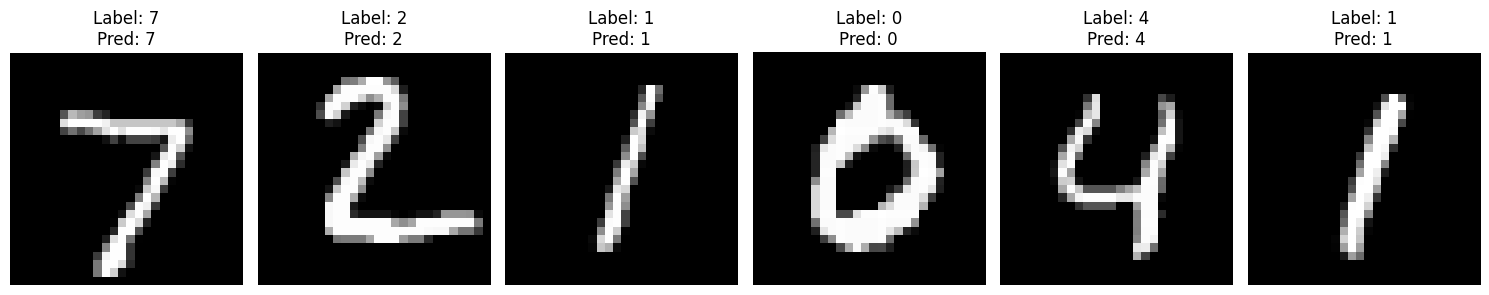

In [ ]:
# Load and evaluate the best model
model.load_state_dict(torch.load('mnist_model.pt'))
model.eval()

# Test predictions
examples = next(iter(test_loader))
images, labels = examples
images, labels = images.to(device), labels.to(device)
outputs = model(images)
preds = torch.argmax(outputs, dim=1)

# Visualize predictions
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for idx in range(6):
    axes[idx].imshow(images[idx].cpu().squeeze(), cmap='gray')
    axes[idx].set_title(f'Label: {labels[idx].item()}\nPred: {preds[idx].item()}')
    axes[idx].axis('off')
plt.tight_layout()
plt.show()
